# Аналіз порівняння двох моделей

У цьому ноутбуці виконується порівняльний аналіз двох навчених моделей:

- **Custom CNN** — власна згорткова нейронна мережа;
- **ResNet18 Gray** — ResNet18, адаптована для одноканальних grayscale-зображень.

Порівняння виконується за такими критеріями:

- loss;
- accuracy;
- precision;
- recall;
- F1-score;
- кількість параметрів;
- середній час інференсу одного зображення.


## 1. Імпорт бібліотек

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

## 2. Завантаження результатів порівняння

Файл `model_comparison.json` має містити список словників, де кожен словник описує результати однієї моделі.

In [2]:
comparison_path = Path("../reports/metrics/model_comparison.json")

if not comparison_path.exists():
    raise FileNotFoundError(
        "Файл model_comparison.json не знайдено. "
        "Спочатку запусти: py scripts\\compare_saved_models.py"
    )

with open(comparison_path, "r", encoding="utf-8") as file:
    comparison_results = json.load(file)

comparison_results

[{'model': 'Custom CNN',
  'weights_path': 'saved_models/cnn/model_cnn.pth',
  'loss': 0.4492167324166406,
  'accuracy': 0.8911764705882353,
  'precision': 0.8924040581781832,
  'recall': 0.891087048727071,
  'f1': 0.8895721578755116,
  'parameters': 1207528,
  'avg_inference_time_sec': 0.0009676400352926815},
 {'model': 'ResNet18 Gray',
  'weights_path': 'saved_models/resnet18_gray/model_resnet18_gray.pth',
  'loss': 0.35358792859849264,
  'accuracy': 0.9088235294117647,
  'precision': 0.9093022185661737,
  'recall': 0.9048954122201014,
  'f1': 0.9052716692274717,
  'parameters': 11174344,
  'avg_inference_time_sec': 0.0003486766534693101}]

## 3. Формування таблиці результатів

In [3]:
df = pd.DataFrame(comparison_results)

display_columns = [
    "model",
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "parameters",
    "avg_inference_time_sec",
]

df = df[display_columns]
df

,model,loss,accuracy,precision,recall,f1,parameters,avg_inference_time_sec
0,Custom CNN,0.449217,0.891176,0.892404,0.891087,0.889572,1207528,0.000968
1,ResNet18 Gray,0.353588,0.908824,0.909302,0.904895,0.905272,11174344,0.000349


## 4. Округлення метрик для зручного перегляду

In [4]:
df_rounded = df.copy()

metric_columns = ["loss", "accuracy", "precision", "recall", "f1", "avg_inference_time_sec"]
for column in metric_columns:
    df_rounded[column] = df_rounded[column].round(4)

df_rounded

,model,loss,accuracy,precision,recall,f1,parameters,avg_inference_time_sec
0,Custom CNN,0.4492,0.8912,0.8924,0.8911,0.8896,1207528,0.0010
1,ResNet18 Gray,0.3536,0.9088,0.9093,0.9049,0.9053,11174344,0.0003


## 5. Порівняння основних метрик якості

На цьому графіку порівнюються основні метрики класифікації. Чим вищі значення `accuracy`, `precision`, `recall` та `F1-score`, тим кращою є якість моделі.

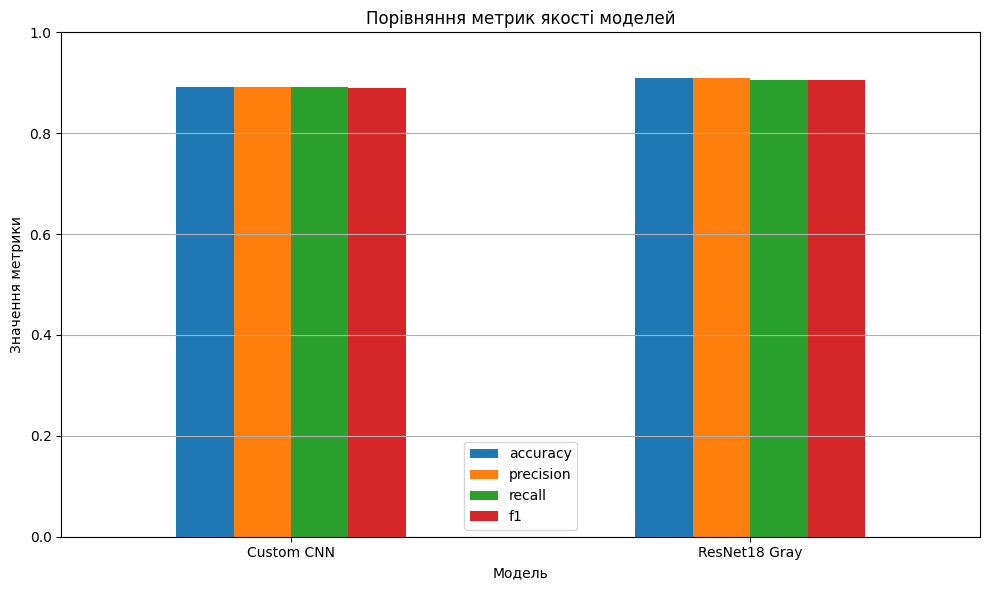

In [5]:
quality_metrics = ["accuracy", "precision", "recall", "f1"]

ax = df.set_index("model")[quality_metrics].plot(kind="bar", figsize=(10, 6))
ax.set_title("Порівняння метрик якості моделей")
ax.set_xlabel("Модель")
ax.set_ylabel("Значення метрики")
ax.set_ylim(0, 1)
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Порівняння loss

Для `loss` кращим є менше значення, оскільки воно показує меншу помилку моделі на тестовій вибірці.

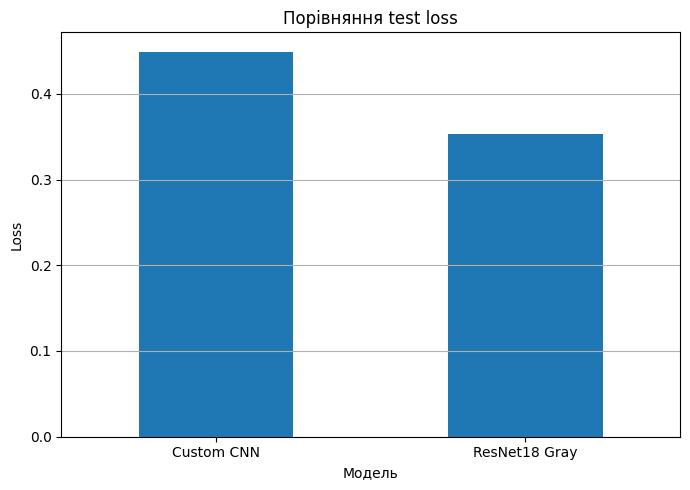

In [6]:
ax = df.plot(x="model", y="loss", kind="bar", legend=False, figsize=(7, 5))
ax.set_title("Порівняння test loss")
ax.set_xlabel("Модель")
ax.set_ylabel("Loss")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Порівняння кількості параметрів

Кількість параметрів показує складність моделі. Модель з меншою кількістю параметрів зазвичай є легшою, швидшою та потребує менше пам’яті.

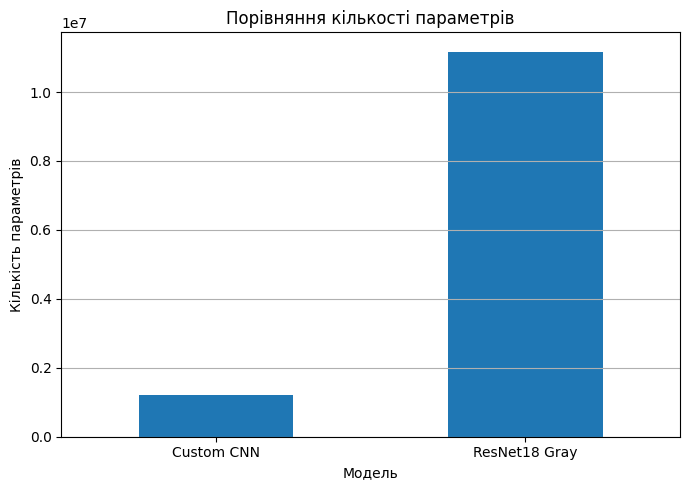

In [7]:
ax = df.plot(x="model", y="parameters", kind="bar", legend=False, figsize=(7, 5))
ax.set_title("Порівняння кількості параметрів")
ax.set_xlabel("Модель")
ax.set_ylabel("Кількість параметрів")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Порівняння середнього часу інференсу

Цей графік показує, скільки часу в середньому потрібно моделі для обробки одного зображення. Менше значення означає швидшу модель.

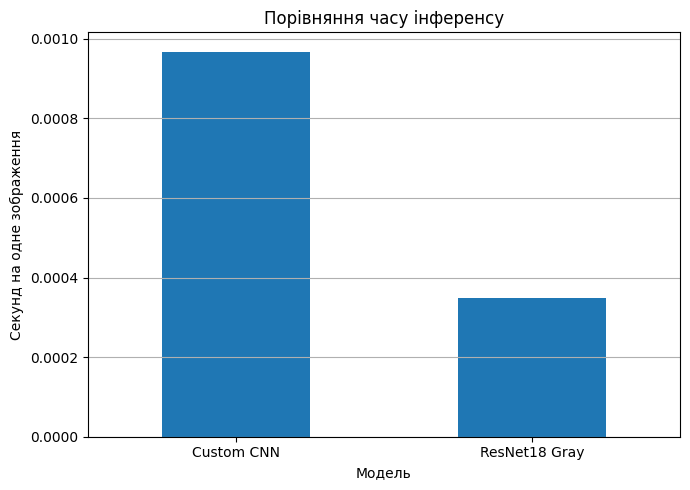

In [8]:
ax = df.plot(x="model", y="avg_inference_time_sec", kind="bar", legend=False, figsize=(7, 5))
ax.set_title("Порівняння часу інференсу")
ax.set_xlabel("Модель")
ax.set_ylabel("Секунд на одне зображення")
ax.grid(axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Визначення кращої моделі за показниками

In [9]:
best_accuracy_model = df.loc[df["accuracy"].idxmax()]
best_f1_model = df.loc[df["f1"].idxmax()]
fastest_model = df.loc[df["avg_inference_time_sec"].idxmin()]
lightest_model = df.loc[df["parameters"].idxmin()]

print("Найкраща модель за accuracy:", best_accuracy_model["model"], "—", round(best_accuracy_model["accuracy"], 4))
print("Найкраща модель за F1-score:", best_f1_model["model"], "—", round(best_f1_model["f1"], 4))
print("Найшвидша модель:", fastest_model["model"], "—", round(fastest_model["avg_inference_time_sec"], 6), "sec/img")
print("Найлегша модель:", lightest_model["model"], "—", int(lightest_model["parameters"]), "parameters")

Найкраща модель за accuracy: ResNet18 Gray — 0.9088
Найкраща модель за F1-score: ResNet18 Gray — 0.9053
Найшвидша модель: ResNet18 Gray — 0.000349 sec/img
Найлегша модель: Custom CNN — 1207528 parameters


## 10. Висновок


In [11]:
quality_winner = best_f1_model["model"]
speed_winner = fastest_model["model"]
light_winner = lightest_model["model"]

conclusion = f"""
За результатами порівняння двох моделей було встановлено, що найкраще значення F1-score показала модель {quality_winner}.
Це означає, що саме ця модель має найкращий баланс між precision та recall на тестовій вибірці.
Найшвидшою за середнім часом інференсу одного зображення виявилася модель {speed_winner}.
Найменшу кількість параметрів має модель {light_winner}, тому вона є легшою з точки зору обчислювальних ресурсів.

Під час вибору фінальної моделі потрібно враховувати не лише точність класифікації, але й складність моделі, швидкість роботи та зручність використання.
Якщо головним критерієм є максимальна якість класифікації, доцільно обирати модель із кращими accuracy та F1-score.
Якщо важливими є швидкість і компактність, перевагу може мати легша модель із меншою кількістю параметрів.
"""

print(conclusion)


За результатами порівняння двох моделей було встановлено, що найкраще значення F1-score показала модель ResNet18 Gray.
Це означає, що саме ця модель має найкращий баланс між precision та recall на тестовій вибірці.
Найшвидшою за середнім часом інференсу одного зображення виявилася модель ResNet18 Gray.
Найменшу кількість параметрів має модель Custom CNN, тому вона є легшою з точки зору обчислювальних ресурсів.

Під час вибору фінальної моделі потрібно враховувати не лише точність класифікації, але й складність моделі, швидкість роботи та зручність використання.
Якщо головним критерієм є максимальна якість класифікації, доцільно обирати модель із кращими accuracy та F1-score.
Якщо важливими є швидкість і компактність, перевагу може мати легша модель із меншою кількістю параметрів.

